# ETC Impacts on the Great Lakes: Build GMM Model

This notebook prepares the storm-feature dataset used for clustering, evaluates candidate Gaussian mixture models, assesses the stability of the selected solution, and fits the final model used in the downstream analysis.

Because evaporation over the lakes is not trusted in ERA5 for this application, the final clustering model is fit using the CFSR dataset.

In [7]:
# ------------------------------
# 1. Imports and setup
# ------------------------------
from pathlib import Path
import sys
import importlib
import json
import random

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# Resolve repository paths
REPO_ROOT = Path.cwd().resolve().parent
DATA_DIR = REPO_ROOT / "data"
PROCESSED_DIR = REPO_ROOT / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)

# Make repo importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.pipeline
importlib.reload(src.pipeline)

from src.pipeline import add_season, clean_teleconnections

sns.set_theme(style="whitegrid")

print("Repo root:", REPO_ROOT)
print("Data dir:", DATA_DIR)
print("Processed dir:", PROCESSED_DIR)

Repo root: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes
Data dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/data
Processed dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed


## Define variables and helper function

We begin by defining the storm-property variables used for clustering, the additional variables retained for downstream analysis, and a helper function that loads and cleans the ERA5 and CFSR datasets in a consistent way.

In [8]:
# ------------------------------
# 2. Variable definitions
# ------------------------------
storm_vars = [
    "min_p_cent",
    "max_p_grad",
    "max_radius",
    "max_uv",
    "fraction_of_time_in_GLR",
    "maturity_glr0_minus_genesis_ratio",
]

impact_vars = [
    "sup_ttl_precip",
    "mi_ttl_precip",
    "huron_ttl_precip",
    "erie_ttl_precip",
    "ont_ttl_precip",
    "sup_ttl_evap_anom",
    "mi_ttl_evap_anom",
    "huron_ttl_evap_anom",
    "erie_ttl_evap_anom",
    "ont_ttl_evap_anom",
]

teleconnection_cols = [
    "amo_unsmoothed_value",
    "ao_value",
    "ea_wr_value",
    "enso_best_value",
    "ipo_value",
    "nao_value",
    "pdo_value",
    "pna_value",
    "pol_value",
    "qbo_value",
    "wp_value",
]

passthrough_cols = [
    "lat_gen",
    "lon_gen",
    "year",
    "month",
    "season",
] + teleconnection_cols

final_cols = storm_vars + impact_vars + passthrough_cols

features_to_cluster = storm_vars

In [9]:
# ------------------------------
# 3. Helper function
# ------------------------------
def build_features(csv_path, *, is_cfsr=False):
    df = pd.read_csv(csv_path)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    add_season(df)
    clean_teleconnections(df)

    if is_cfsr:
        df = df[
            (df["fraction_of_time_in_GLR"] >= 0)
            & (df["maturity_glr0_minus_genesis_ratio"] >= 0)
        ].copy()

    missing = [col for col in final_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in {Path(csv_path).name}: {missing}")

    out = df[final_cols].copy()

    if out.columns.duplicated().any():
        dupes = out.columns[out.columns.duplicated()].tolist()
        raise ValueError(f"Duplicate columns in output: {dupes}")

    return out

## Load and clean the ERA5 and CFSR feature tables

The feature tables saved here provide a consistent starting point for the clustering and impact-analysis workflow.

In [10]:
# ------------------------------
# 4. Build cleaned feature tables
# ------------------------------
df_era5 = build_features(DATA_DIR / "era5_etc.csv", is_cfsr=False)
df_cfsr = build_features(DATA_DIR / "cfsr_etc.csv", is_cfsr=True)

print("ERA5 feature table shape:", df_era5.shape)
print("CFSR feature table shape:", df_cfsr.shape)

df_era5.to_csv(PROCESSED_DIR / "era5_features.csv", index=False)
df_cfsr.to_csv(PROCESSED_DIR / "cfsr_features.csv", index=False)

print("Saved cleaned feature tables.")

ERA5 feature table shape: (6136, 32)
CFSR feature table shape: (3384, 32)
Saved cleaned feature tables.


## Prepare clustering inputs

We now subset to the storm-property variables used for clustering and standardize them before fitting Gaussian mixture models.

In [11]:
# ------------------------------
# 5. Prepare clustering inputs
# ------------------------------
df_era5 = df_era5.dropna(subset=features_to_cluster).copy()
df_cfsr = df_cfsr.dropna(subset=features_to_cluster).copy()

X_era5 = df_era5[features_to_cluster].copy()
X_cfsr = df_cfsr[features_to_cluster].copy()

scaler = StandardScaler()

X_cfsr_scaled = pd.DataFrame(
    scaler.fit_transform(X_cfsr),
    columns=X_cfsr.columns,
    index=X_cfsr.index,
)

X_era5_scaled = pd.DataFrame(
    scaler.transform(X_era5),
    columns=X_era5.columns,
    index=X_era5.index,
)

print("CFSR clustering matrix shape:", X_cfsr_scaled.shape)
print("ERA5 clustering matrix shape:", X_era5_scaled.shape)

CFSR clustering matrix shape: (3316, 6)
ERA5 clustering matrix shape: (6136, 6)


## Compare candidate models across a range of cluster numbers

To guide model selection, we fit Gaussian mixture models with several values of K on repeated subsamples of the CFSR clustering matrix and summarize the resulting metrics.

In [12]:
# ------------------------------
# 6. Subsampled model comparison
# ------------------------------
n_subsamples = 30
sample_frac = 0.8
k_range = range(2, 6)

results = []

for k in k_range:
    for _ in range(n_subsamples):
        sample_idx = random.sample(
            range(len(X_cfsr_scaled)),
            int(sample_frac * len(X_cfsr_scaled))
        )
        X_sample = X_cfsr_scaled.iloc[sample_idx]

        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=42,
            n_init=5,
        )
        labels = gmm.fit_predict(X_sample)

        results.append(
            {
                "K": k,
                "silhouette": silhouette_score(X_sample, labels),
                "log_likelihood": gmm.score(X_sample) * len(X_sample),
                "bic": gmm.bic(X_sample),
                "aic": gmm.aic(X_sample),
            }
        )

metrics_df = pd.DataFrame(results)
metrics_df.head()

,K,silhouette,log_likelihood,bic,aic
0,2,0.199347,-19149.360933,38732.290681,38408.721867
1,2,0.193940,-19089.041277,38611.651369,38288.082555
2,2,0.196776,-19074.134454,38581.837721,38258.268907
3,2,0.194303,-19144.325286,38722.219387,38398.650573
4,2,0.200270,-19130.996207,38695.561227,38371.992413


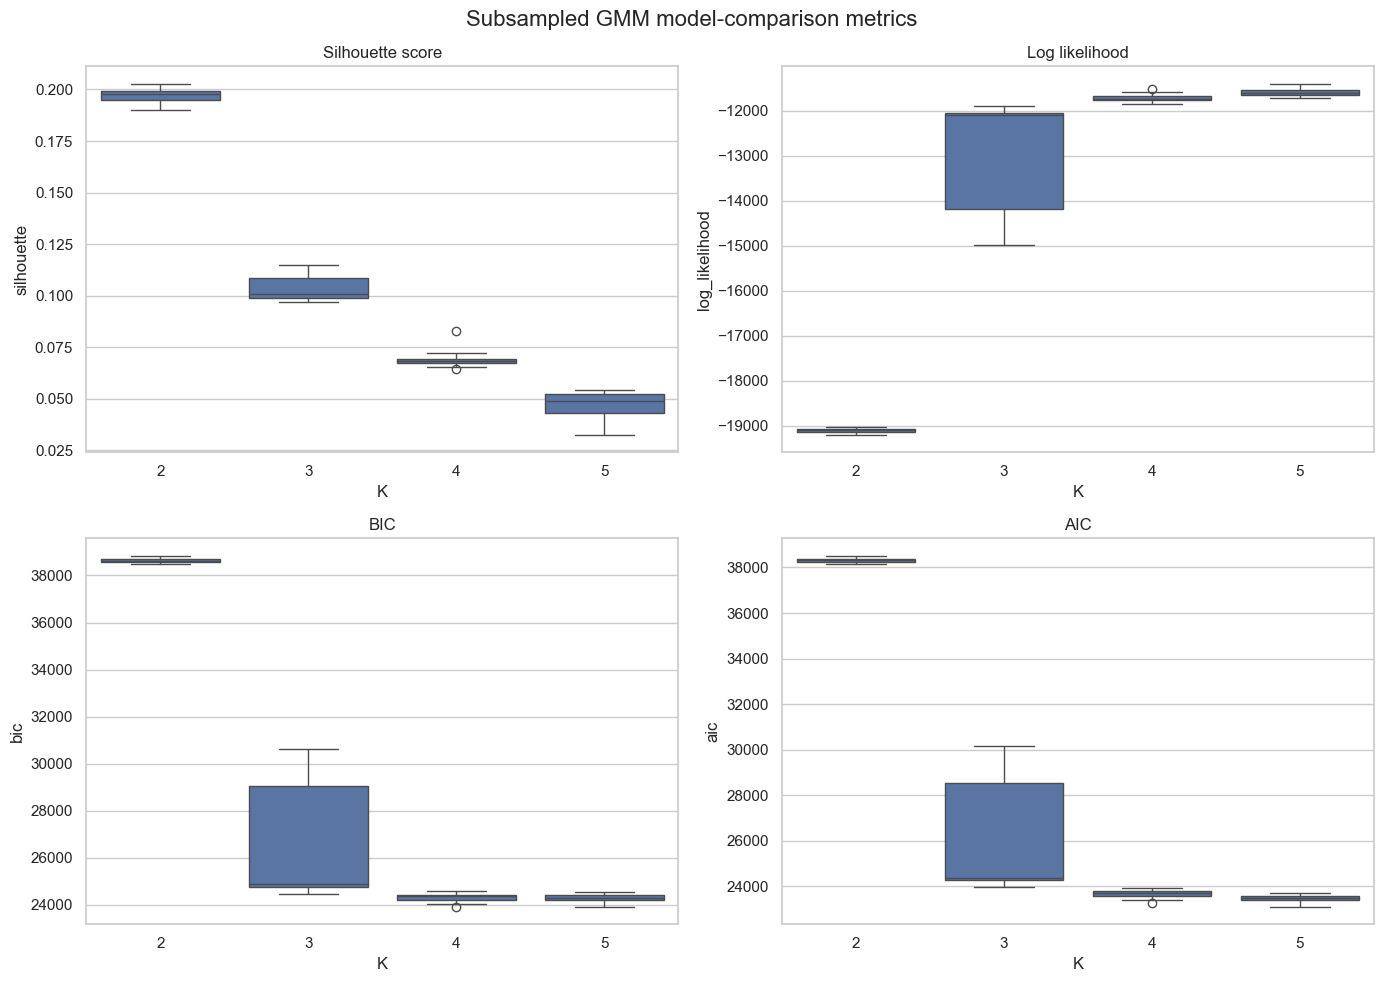

In [13]:
# ------------------------------
# 7. Visualize model-comparison metrics
# ------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=metrics_df, x="K", y="silhouette", ax=axs[0, 0])
axs[0, 0].set_title("Silhouette score")

sns.boxplot(data=metrics_df, x="K", y="log_likelihood", ax=axs[0, 1])
axs[0, 1].set_title("Log likelihood")

sns.boxplot(data=metrics_df, x="K", y="bic", ax=axs[1, 0])
axs[1, 0].set_title("BIC")

sns.boxplot(data=metrics_df, x="K", y="aic", ax=axs[1, 1])
axs[1, 1].set_title("AIC")

plt.suptitle("Subsampled GMM model-comparison metrics", fontsize=16)
plt.tight_layout()
plt.show()

## Assess stability of the selected K=2 solution

Given the preference for a two-cluster solution, we next assess the stability of the K=2 classification using repeated subsampling of the CFSR clustering matrix.

In [14]:
# ------------------------------
# 8. Stability analysis for K=2
# ------------------------------
k_best = 2

label_matrix_k2 = []
posterior_probs_k2 = []
subsample_indices_k2 = []

for _ in range(n_subsamples):
    sample_idx = random.sample(
        range(len(X_cfsr_scaled)),
        int(sample_frac * len(X_cfsr_scaled))
    )
    X_sample = X_cfsr_scaled.iloc[sample_idx]

    gmm_k2 = GaussianMixture(
        n_components=k_best,
        covariance_type="full",
        random_state=42,
        n_init=5,
    )
    gmm_k2.fit(X_sample)

    probs_k2 = gmm_k2.predict_proba(X_sample)
    labels_k2 = gmm_k2.predict(X_sample)

    label_matrix_k2.append(labels_k2)
    posterior_probs_k2.append(probs_k2.max(axis=1))
    subsample_indices_k2.append(sample_idx)

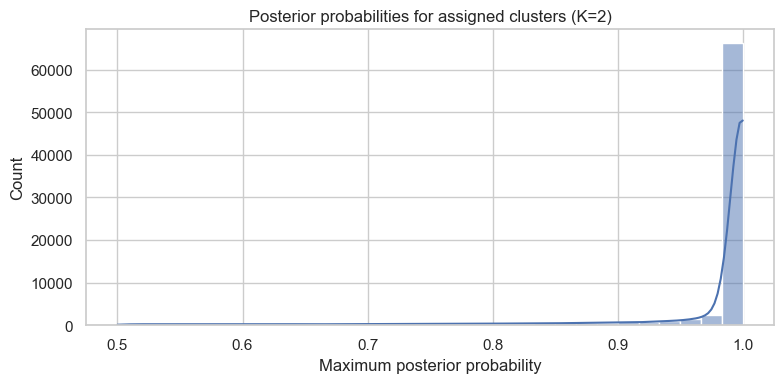

In [15]:
plt.figure(figsize=(8, 4))
all_probs_k2 = np.concatenate(posterior_probs_k2)

sns.histplot(all_probs_k2, bins=30, kde=True)
plt.title("Posterior probabilities for assigned clusters (K=2)")
plt.xlabel("Maximum posterior probability")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [16]:
mapped_ari_scores_k2 = []
n_runs = len(label_matrix_k2)

for i in range(n_runs):
    for j in range(i + 1, n_runs):
        idx_i = subsample_indices_k2[i]
        idx_j = subsample_indices_k2[j]

        shared_idx = list(set(idx_i) & set(idx_j))
        if not shared_idx:
            continue

        pos_i = [idx_i.index(x) for x in shared_idx]
        pos_j = [idx_j.index(x) for x in shared_idx]

        labels_i = label_matrix_k2[i][pos_i]
        labels_j = label_matrix_k2[j][pos_j]

        ari = adjusted_rand_score(labels_i, labels_j)
        mapped_ari_scores_k2.append(ari)

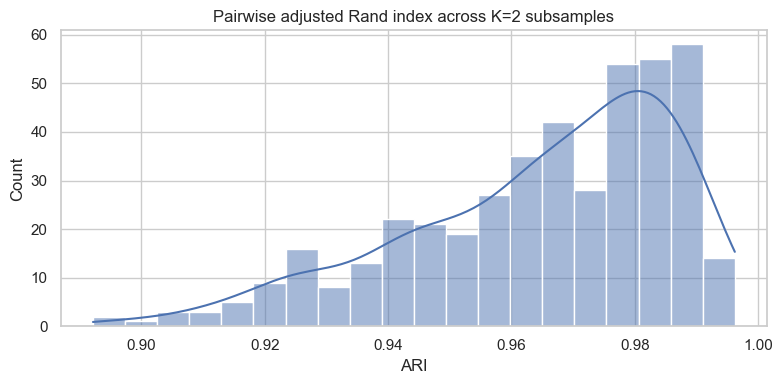

ARI summary:
count    435.000000
mean       0.964605
std        0.021651
min        0.892137
25%        0.950704
50%        0.969928
75%        0.981255
max        0.996235
dtype: float64


In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(mapped_ari_scores_k2, bins=20, kde=True)
plt.title("Pairwise adjusted Rand index across K=2 subsamples")
plt.xlabel("ARI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("ARI summary:")
print(pd.Series(mapped_ari_scores_k2).describe())

## Fit the final K=2 model on CFSR

We now fit the final K=2 Gaussian mixture model on the full CFSR clustering matrix and save the resulting labeled storm tables and model artifacts for downstream analysis.

In [18]:
# ------------------------------
# 9. Fit final model on CFSR
# ------------------------------
final_gmm_k2 = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42,
    n_init=5,
)
final_gmm_k2.fit(X_cfsr_scaled)

df_cfsr["k2_cluster"] = final_gmm_k2.predict(X_cfsr_scaled)
df_cfsr["k2_posterior"] = final_gmm_k2.predict_proba(X_cfsr_scaled).max(axis=1)

print(df_cfsr[["k2_cluster", "k2_posterior"]].head())

   k2_cluster  k2_posterior
0           0      0.999535
2           1      0.991803
3           1      0.999581
4           1      0.999998
5           0      1.000000


In [19]:
# ------------------------------
# 10. Apply final CFSR model to ERA5
# ------------------------------
df_era5["k2_cluster"] = final_gmm_k2.predict(X_era5_scaled)
df_era5["k2_posterior"] = final_gmm_k2.predict_proba(X_era5_scaled).max(axis=1)

print(df_era5[["k2_cluster", "k2_posterior"]].head())

   k2_cluster  k2_posterior
0           1      0.999821
1           1      1.000000
2           1      0.999998
3           1      0.999991
4           1      1.000000


## Save outputs

The processed feature tables, labeled storm tables, and fitted model artifacts are saved to the `processed/` directory for use in the downstream impact-analysis and figure-generation notebooks.

In [20]:
# ------------------------------
# 11. Save outputs
# ------------------------------
df_era5.to_csv(PROCESSED_DIR / "era5_storms_labeled_k2.csv", index=False)
df_cfsr.to_csv(PROCESSED_DIR / "cfsr_storms_labeled_k2.csv", index=False)

joblib.dump(scaler, PROCESSED_DIR / "scaler.joblib")
joblib.dump(final_gmm_k2, PROCESSED_DIR / "final_gmm_k2.joblib")

with open(PROCESSED_DIR / "features.json", "w") as f:
    json.dump(features_to_cluster, f, indent=2)

print("Saved:")
print("-", PROCESSED_DIR / "era5_features.csv")
print("-", PROCESSED_DIR / "cfsr_features.csv")
print("-", PROCESSED_DIR / "era5_storms_labeled_k2.csv")
print("-", PROCESSED_DIR / "cfsr_storms_labeled_k2.csv")
print("-", PROCESSED_DIR / "scaler.joblib")
print("-", PROCESSED_DIR / "final_gmm_k2.joblib")
print("-", PROCESSED_DIR / "features.json")

Saved:
- /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed/era5_features.csv
- /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed/cfsr_features.csv
- /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed/era5_storms_labeled_k2.csv
- /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed/cfsr_storms_labeled_k2.csv
- /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed/scaler.joblib
- /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed/final_gmm_k2.joblib
- /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed/features.json


## Summary

This notebook builds the cleaned feature tables used in the clustering workflow, compares candidate Gaussian mixture models, assesses the stability of the selected K=2 solution, and saves the final labeled storm datasets and model artifacts for downstream analysis.